In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
DATABASE = "nsrdb"
RECORD = "16272"
CHANNEL = 0
SAMPFROM = 0
SAMPLING_POINTS = 3600
print("Parámetros configurados")

Parámetros configurados


In [3]:
record = wfdb.rdrecord(RECORD, pn_dir = DATABASE, sampfrom=SAMPFROM, sampto=SAMPFROM+SAMPLING_POINTS)
x = record.p_signal[:, CHANNEL]
fs = record.fs
print("Muestras", len(x))
print("Frecuencia de muestreo", fs)

Muestras 3600
Frecuencia de muestreo 128


STFT con ventana 32 lista


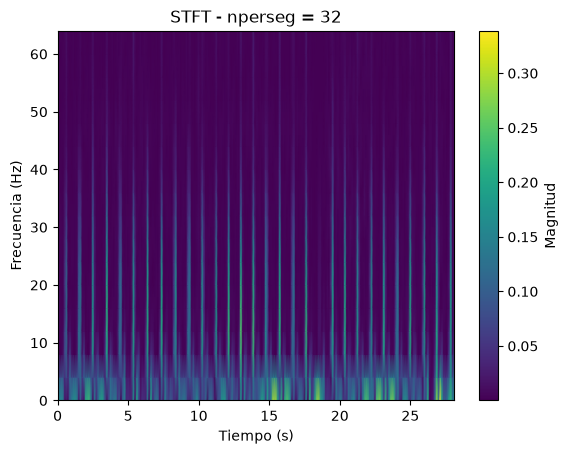

In [4]:
f32, t32, Z32 = signal.stft(x, fs, nperseg = 32)
print("STFT con ventana 32 lista")

plt.pcolormesh(t32, f32, np.abs(Z32), shading='gouraud')
plt.title("STFT - nperseg = 32")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.colorbar(label="Magnitud")
plt.show()


STFT con ventana 128 lista


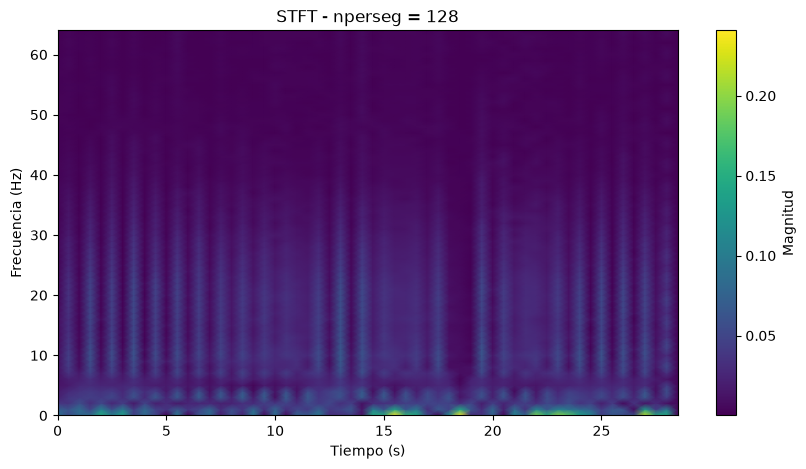

In [5]:
f128, t128, Z128 = signal.stft(x, fs, nperseg = 128)
print("STFT con ventana 128 lista")

plt.figure(figsize=(10, 5))

plt.pcolormesh(t128, f128, np.abs(Z128), shading='gouraud')
plt.title("STFT - nperseg = 128")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.colorbar(label="Magnitud")
plt.show()

STFT con ventana 256 lista


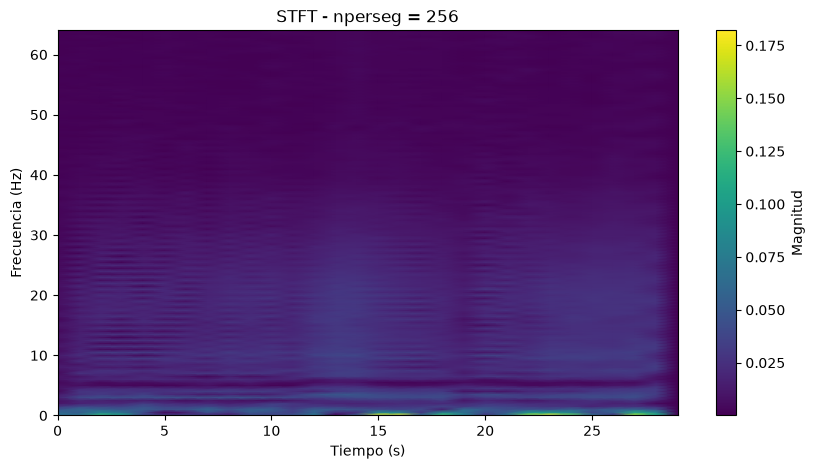

In [6]:
f256, t256, Z256 = signal.stft(x, fs, nperseg = 256)
print("STFT con ventana 256 lista")

plt.figure(figsize=(10, 5))
plt.pcolormesh(t256, f256, np.abs(Z256), shading='gouraud')
plt.title("STFT - nperseg = 256")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.colorbar(label="Magnitud")
plt.show()

Para este registro ECG, la ventana nperseg = 128 resulta mas adecuada  debido a que presenta un compromiso entre resolución temporal y frecuencial. Permite identificar los eventos asociados a los latidos menteniendo una representación adecuada de las componentes frecuenciales de la señal. Aunque nperseg=32 ofrece mayor detalle temporal y nperseg=256 mayor detalle frecuencial, ambas sacrifican información imporante de otro dominio.